In [27]:
# Import required libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


In [28]:
# Configuration
CONFIG = {
    'embedding_dim': 64,  # D - configurable embedding dimension
    'hidden_dim': 256,      # Hidden dimension for Q/K projections
    'batch_size': 32,       # Batch size for training
    'learning_rate': 1e-3,  # Learning rate
    'n_samples': 20000,     # Total number of samples for both train and validation
    'mlp_hidden_dim': 512, # Hidden dimension for random MLPs
    'mlp_n_layers': 3,      # Number of layers in random MLPs
    'use_attention_scores': False, # Use attention scores instead of weights
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(f"\nDevice: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Configuration:
  embedding_dim: 64
  hidden_dim: 256
  batch_size: 32
  learning_rate: 0.001
  n_samples: 20000
  mlp_hidden_dim: 512
  mlp_n_layers: 3
  use_attention_scores: False

Device: cpu


## 1. Data Preparation and Embedding Generation

We start by loading the single-cell transcriptome data from `Single_Cell_TPM_threshold2.csv`. This dataset contains gene expression data for ~13,669 genes across 128 neuron classes, providing much more granular resolution than bulk-sorted data.

Our approach:
1. Load and preprocess the transcriptome data
2. Apply log1p transformation and standardization
3. Perform PCA to reduce dimensionality to D=1024
4. Generate initial (N, D) embedding matrix where N=128 neuron classes


In [29]:
# # Load single-cell transcriptome data from Single_Cell_TPM_threshold2.csv

# print("Loading transcriptome data...")
# df = pd.read_csv('data/Single_Cell_TPM_threshold2.csv', index_col=0)

# print(f"Original data shape: {df.shape}")
# print(f"Columns (first 10): {df.columns[:10].tolist()}")
# print(f"Index (first 10): {df.index[:10].tolist()}")

# # Skip gene metadata columns and get neuron class columns
# gene_metadata_cols = ['Gene_Name', 'Sequence_Name', 'Wormbase_ID']
# neuron_cols = [col for col in df.columns if col not in gene_metadata_cols]
# gene_names = df.index.tolist()

# print(f"\nGene metadata columns: {gene_metadata_cols}")
# print(f"Number of neuron classes: {len(neuron_cols)}")
# print(f"Neuron classes (first 10): {neuron_cols[:10]}")
# print(f"Gene names (first 10): {gene_names[:10]}")

# # Extract expression data (genes x neurons)
# X = df[neuron_cols].values  # Shape: (n_genes, n_neurons)
# print(f"\nExpression matrix shape: {X.shape}")

# # Transpose to (neurons x genes) format
# X = X.T  # Shape: (n_neurons, n_genes)
# print(f"Transposed expression matrix shape: {X.shape}")

# # Apply log1p transformation to compress dynamic range
# X_log = np.log1p(X)
# print(f"After log1p transformation - min: {X_log.min():.3f}, max: {X_log.max():.3f}")

# # Standardize features (genes)
# scaler = StandardScaler(with_mean=True, with_std=True)
# X_scaled = scaler.fit_transform(X_log)
# print(f"After standardization - mean: {X_scaled.mean():.6f}, std: {X_scaled.std():.6f}")

# # Store neuron class names
# neuron_classes = neuron_cols
# N_neurons = len(neuron_classes)
# print(f"\nNumber of neuron classes: {N_neurons}")
# print(f"Neuron classes: {neuron_classes}")


In [30]:
# Load GSE136049 neuron-class transcriptome (preferring log-normalized means)

preferred_path = 'GSE136049_genes_by_neurons_lognorm_means.csv'
counts_path    = 'GSE136049_genes_by_neurons_counts.csv'

if os.path.exists(preferred_path):
    df = pd.read_csv(preferred_path, index_col=0)
    used = preferred_path
    X = df.T.values  # neurons x genes
else:
    assert os.path.exists(counts_path), "Missing GSE136049 CSVs; run load_data.ipynb first."
    df = pd.read_csv(counts_path, index_col=0)
    used = counts_path
    # counts → log1p before standardization
    X = np.log1p(df.T.values)

neuron_classes = df.columns.tolist()
transcript_names = df.index.tolist()
print(f"Loaded: {used}")
print(f"Original table shape (genes x neuron_classes): {df.shape}")
print(f"Transposed to (neurons x genes): {X.shape}")
print(f"Neuron classes (sample 10): {neuron_classes[:10]}")
print(f"Genes (sample 10): {transcript_names[:10]}")

# Standardize features (per gene)
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)
print(f"After standardization - mean: {X_scaled.mean():.6f}, std: {X_scaled.std():.6f}")

N_neurons = len(neuron_classes)
print(f"Number of neuron classes: {N_neurons}")


Loaded: GSE136049_genes_by_neurons_lognorm_means.csv
Original table shape (genes x neuron_classes): (22469, 130)
Transposed to (neurons x genes): (130, 22469)
Neuron classes (sample 10): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY']
Genes (sample 10): ['2L52.1a.1', '2L52.2', '2RSSE.1a.1', '2RSSE.5', '2RSSE.7', '3R5.1a.1', '3R5.2', '4R79.1a.1', '4R79.2a.1', 'AC3.10.1']
After standardization - mean: -0.000000, std: 0.978950
Number of neuron classes: 130


Performing PCA to reduce to 64 dimensions...
Max possible components: 129
Using 64 components
PCA reduced data shape: (130, 64)
Explained variance ratio (first 5 components): [0.06212029 0.03978368 0.02996014 0.02838265 0.0238292 ]
Total explained variance: 0.727


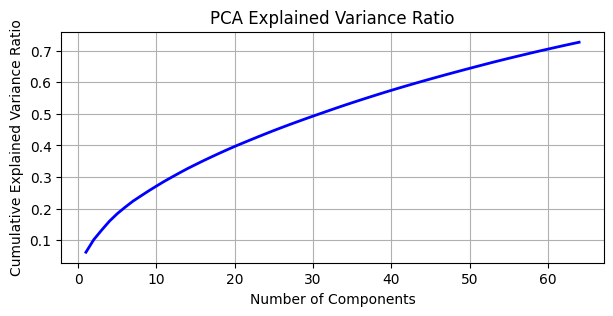

Final embeddings shape: (130, 64)

Original embeddings stored. Shape: torch.Size([130, 64]). Dtype: torch.float32
Original embeddings mean (first 3 neurons): tensor([2.2352e-08, 3.7253e-09, 1.8626e-08])
Original embeddings std (first 3 neurons): tensor([1.0079, 1.0079, 1.0079])


In [31]:
# Perform PCA to reduce dimensionality
D = CONFIG['embedding_dim']
print(f"Performing PCA to reduce to {D} dimensions...")

# Determine number of components (can't exceed min(n_neurons-1, n_genes))
max_components = min(N_neurons - 1, X_scaled.shape[1])
n_components = min(D, max_components)

print(f"Max possible components: {max_components}")
print(f"Using {n_components} components")

# Fit PCA
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA reduced data shape: {X_pca.shape}")
# Print numerical summary
print(f"Explained variance ratio (first 5 components): {pca.explained_variance_ratio_[:5]}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Plot explained variance ratio curve
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 
         'b-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.grid(True)
plt.show()

# If we need more dimensions, pad with zeros
if n_components < D:
    padding = np.zeros((X_pca.shape[0], D - n_components))
    X_embeddings = np.concatenate([X_pca, padding], axis=1)
    print(f"Padded embeddings shape: {X_embeddings.shape}")
else:
    X_embeddings = X_pca
    print(f"Final embeddings shape: {X_embeddings.shape}")


# Store what we'll use as the original embedding matrix for the dataset
layernorm = torch.nn.LayerNorm(X_embeddings.shape[-1], elementwise_affine=False, bias=False)
with torch.no_grad():
    embeddings = torch.tensor(X_embeddings, dtype=torch.float32)
    # original_embeddings = embeddings.clone()
    # Normalize embeddings to lie on unit sphere
    original_embeddings = layernorm(embeddings).clone()
#  Each neuron's embedding now has 0-mean and unit variance
print(f"\nOriginal embeddings stored. Shape: {original_embeddings.shape}. Dtype: {original_embeddings.dtype}")
print(f"Original embeddings mean (first 3 neurons): {original_embeddings.mean(dim=-1)[:3]}")
print(f"Original embeddings std (first 3 neurons): {original_embeddings.std(dim=-1)[:3]}")


## 2. Custom Dataset with Random Projection Augmentation

Since we have only one (N, D) embedding matrix from the original transcriptome data, we need to generate multiple training samples. Our innovation is to create synthetic but meaningful variations using random MLP projections.

**Key insight**: Each random MLP transforms all N neurons identically (N acts as a batch dimension), preserving the relative relationships between neuron embeddings while creating novel projections. This allows generation of effectively unlimited training samples.


In [32]:
class RandomMLP(nn.Module):
    """Random MLP for generating augmented embeddings."""
    
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim=None, nonlinearity=None):
        super().__init__()
        if output_dim is None:
            output_dim = input_dim
            
        layers = []
        current_dim = input_dim
        
        for i in range(n_layers):
            if i == n_layers - 1:
                # Last layer
                layers.append(nn.Linear(current_dim, output_dim))
            else:
                # Hidden layers
                layers.append(nn.Linear(current_dim, hidden_dim))
                if nonlinearity is not None:
                    layers.append(nonlinearity())
                # No nonlinearities — just a linear random projection
                current_dim = hidden_dim
        
        # Normalize the output to lie on unit sphere
        layernorm = nn.LayerNorm(output_dim, elementwise_affine=False, bias=False)
        layers.append(layernorm)
                
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)


class TranscriptomeEmbeddingDataset(Dataset):
    """Dataset that generates augmented embeddings using random MLP projections on-the-fly."""
    
    def __init__(self, original_embeddings, n_samples, mlp_hidden_dim, mlp_n_layers, nonlinearity=None, seed=None, no_augmentation=False):
        """
        Args:
            original_embeddings: (N, D) tensor of original neuron embeddings
            n_samples: total number of samples in dataset
            mlp_hidden_dim: hidden dimension for random MLPs
            mlp_n_layers: number of layers in random MLPs
            nonlinearity: nonlinearity to use in random MLPs
            seed: random seed for reproducibility
            no_augmentation: if True, always return original embeddings instead of augmented samples
        """
        self.original_embeddings = original_embeddings  # (N, D)
        self.n_samples = n_samples
        self.mlp_hidden_dim = mlp_hidden_dim
        self.mlp_n_layers = mlp_n_layers
        self.nonlinearity = nonlinearity
        self.seed = seed
        self.no_augmentation = no_augmentation
        
        self.N, self.D = original_embeddings.shape
        print(f"Dataset initialized with {self.N} neurons, {self.D} embedding dimensions, {n_samples} samples")
        
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        if self.no_augmentation:
            return self.original_embeddings.clone()
        
        # Generate a random MLP for this sample (on-the-fly)
        if self.seed is not None:
            torch.manual_seed(self.seed + idx)
            
        random_mlp = RandomMLP(
            input_dim=self.D,
            hidden_dim=self.mlp_hidden_dim,
            n_layers=self.mlp_n_layers,
            output_dim=self.D,
            nonlinearity=self.nonlinearity
        )
        
        # Apply the random MLP to all neurons
        with torch.no_grad():
            augmented_embeddings = random_mlp(self.original_embeddings)  # (N, D)
            
        return augmented_embeddings


# Test the dataset creation
print("Testing the dataset...")
dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples=CONFIG['n_samples'],
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    nonlinearity=None,
    seed=42,
    no_augmentation=False
)

# Test a few samples
sample = dataset[0]
print(f"\nSample shape: {sample.shape}, dtype: {sample.dtype}")
print(f"Sample mean (first 3 neurons): {sample.mean(dim=-1)[:3]}")
print(f"Sample std (first 3 neurons): {sample.std(dim=-1)[:3]}")

# Test that sample is different from original embeddings
diff = torch.norm(sample - original_embeddings).item()
print(f"Difference between sample and original embeddings: {diff:.3f}")

# Test that different samples are different
sample2 = dataset[1]
diff = torch.norm(sample - sample2).item()
print(f"Difference between samples 0 and 1: {diff:.3f}")

sampleN = dataset[-1]
diff = torch.norm(sample - sampleN).item()
print(f"Difference between samples 0 and {len(dataset)-1}: {diff:.3f}")

# Create data loader
dataloader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)
batch = next(iter(dataloader))
print(f"Batch shape: {batch.shape}")
print(f"Batch dtype: {batch.dtype}")

Testing the dataset...
Dataset initialized with 130 neurons, 64 embedding dimensions, 20000 samples

Sample shape: torch.Size([130, 64]), dtype: torch.float32
Sample mean (first 3 neurons): tensor([ 1.4901e-08, -1.1176e-08,  3.7253e-09])
Sample std (first 3 neurons): tensor([1.0077, 1.0078, 1.0078])
Difference between sample and original embeddings: 129.416
Difference between samples 0 and 1: 127.812
Difference between samples 0 and 19999: 130.503
Batch shape: torch.Size([32, 130, 64])
Batch dtype: torch.float32


### Sanity Check: Preserving Neuron Relationships

Let's verify that our random projection augmentation preserves the relative relationships between neuron embeddings. We'll compare 2D PCA plots of the original embeddings with a sample from our dataset.


Performing sanity check on random projection augmentation...


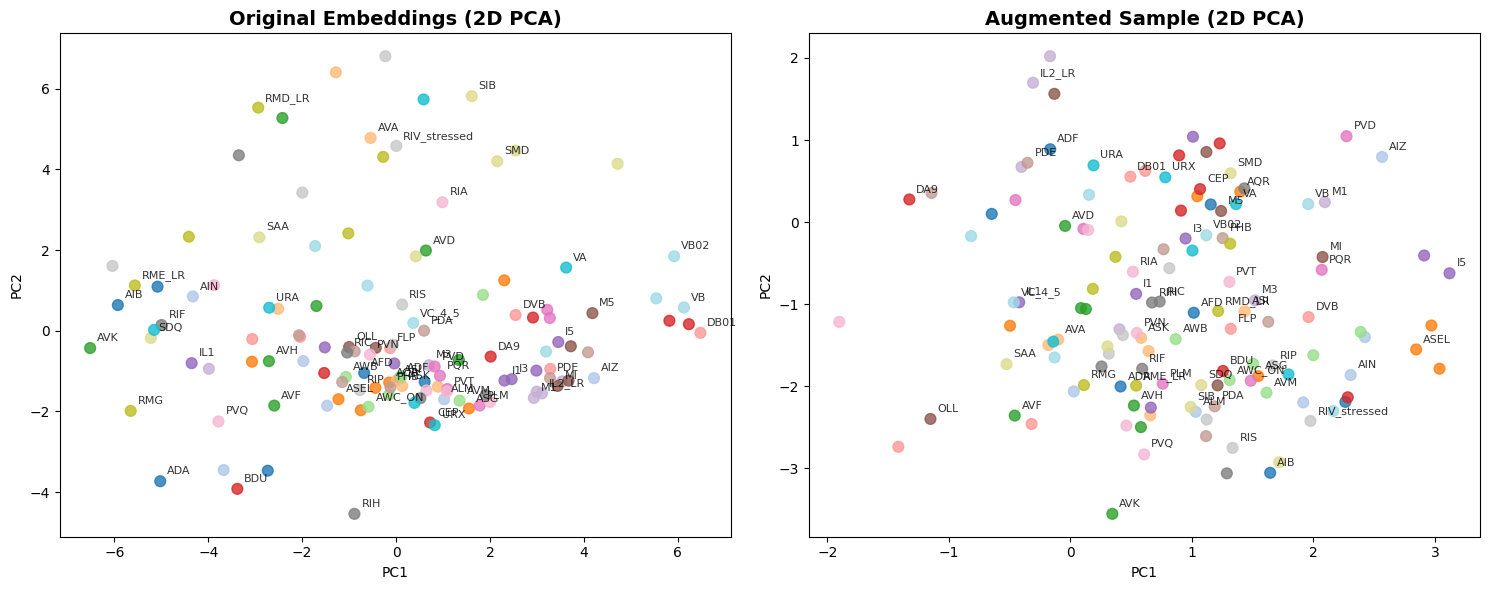


Sanity Check Results:
Correlation between pairwise distances: 0.8213
Original embeddings shape: torch.Size([130, 64])
Sample embeddings shape: (130, 64)

Closest neighbors to AIZ (index 10):
Original: ['DB01', 'VB01', 'VB', 'VB02', 'CEP']
Sample:   ['NSM', 'VB', 'RIA', 'RIC', 'M1']
Overlap:  1/5
✓ PASS: High correlation indicates relationships are preserved!


In [33]:
# Sanity check: Compare original embeddings with augmented sample
from sklearn.decomposition import PCA

print("Performing sanity check on random projection augmentation...")

# Get a sample from our dataset
sample_embeddings = sample.numpy()  # Shape: (N, D)

# Perform 2D PCA on both original and sample embeddings
pca_2d = PCA(n_components=2, random_state=42)

# Original embeddings PCA
original_pca = pca_2d.fit_transform(original_embeddings.numpy())

# Sample embeddings PCA (using same PCA object fitted on original)
sample_pca = pca_2d.transform(sample_embeddings)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot original embeddings
scatter1 = ax1.scatter(original_pca[:, 0], original_pca[:, 1], 
                      c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
ax1.set_title('Original Embeddings (2D PCA)', fontsize=14, fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

# Annotate a few points for reference
for i in range(0, len(neuron_classes), 2):  # Annotate every other neuron
    ax1.annotate(neuron_classes[i], (original_pca[i, 0], original_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

# Plot sample embeddings
scatter2 = ax2.scatter(sample_pca[:, 0], sample_pca[:, 1], 
                      c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
ax2.set_title('Augmented Sample (2D PCA)', fontsize=14, fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

# Annotate the same points for comparison
for i in range(0, len(neuron_classes), 2):  # Annotate every other neuron
    ax2.annotate(neuron_classes[i], (sample_pca[i, 0], sample_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

# Calculate correlation between original and sample embeddings
# Compute pairwise distances between neurons in both embeddings
from scipy.spatial.distance import pdist, squareform

original_distances = pdist(original_embeddings.numpy())
sample_distances = pdist(sample_embeddings)

# Calculate correlation between distance matrices
correlation = np.corrcoef(original_distances, sample_distances)[0, 1]

print(f"\nSanity Check Results:")
print(f"Correlation between pairwise distances: {correlation:.4f}")
print(f"Original embeddings shape: {original_embeddings.shape}")
print(f"Sample embeddings shape: {sample_embeddings.shape}")

# Check if the relative ordering of neurons is preserved
# Find the 5 closest neighbors for a few neurons in both embeddings
test_neuron_idx = 10  # Test with neuron at index 10
original_distances_matrix = squareform(original_distances)
sample_distances_matrix = squareform(sample_distances)

# Get closest neighbors for original
original_neighbors = np.argsort(original_distances_matrix[test_neuron_idx])[1:6]  # Skip self
sample_neighbors = np.argsort(sample_distances_matrix[test_neuron_idx])[1:6]  # Skip self

print(f"\nClosest neighbors to {neuron_classes[test_neuron_idx]} (index {test_neuron_idx}):")
print(f"Original: {[neuron_classes[i] for i in original_neighbors]}")
print(f"Sample:   {[neuron_classes[i] for i in sample_neighbors]}")
print(f"Overlap:  {len(set(original_neighbors) & set(sample_neighbors))}/5")

if correlation > 0.8:
    print("✓ PASS: High correlation indicates relationships are preserved!")
else:
    print("⚠ WARNING: Low correlation - relationships may not be preserved")


## 3. Attention Model Architecture

We implement the `AttentionHeads` module that learns to reconstruct each neuron's embedding using only the embeddings of other neurons. The key innovation is the diagonal masking that prevents self-attention, forcing the model to learn how to combine information from other neurons.

**Architecture**:
- Input: (batch, N, D) tensor of neuron embeddings
- Output: reconstructed embeddings and attention weights
- Diagonal mask: A[i,i] = 0 (prevent self-attention)
- Multi-head attention for learning diverse connectivity patterns


In [34]:
class AttentionHeads(nn.Module):
    def __init__(self, d_model, n_hidden, use_attention_scores=False):
        """
        Simplified attention model with single head and value projection.
        Uses value projection to d_model so no output projection needed.
        
        Args:
            d_model: the dimension of the input tokens (D)
            n_hidden: the hidden dimension for Q/K projections
            use_attention_scores: if True, use attention scores instead of weights to attend to values
        """
        super().__init__()
        # Q, K, and V projections
        self.W_Q = nn.Linear(d_model, n_hidden)  # Query projection
        self.W_K = nn.Linear(d_model, n_hidden)  # Key projection
        self.W_V = nn.Linear(d_model, d_model)   # Value projection (output dim = d_model)
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores

    def forward(self, x, attn_mask=None):
        """
        Args:
            x: input token tensor of shape (batch, n_neurons, d_model)
            attn_mask: optional mask tensor of shape (batch, n_neurons, n_neurons)

        Returns:
            reconstructed: reconstructed embeddings of shape (batch, n_neurons, d_model)
            attn_weights: attention weights of shape (batch, n_neurons, n_neurons)
            attn_scores: attention scores of shape (batch, n_neurons, n_neurons)
        """
        batch_size, n_neurons, d_model = x.shape

        # Compute Q, K, V projections
        Q = self.W_Q(x)  # (batch, n_neurons, n_hidden)
        K = self.W_K(x)  # (batch, n_neurons, n_hidden)
        V = self.W_V(x)  # (batch, n_neurons, d_model)

        # Default to diagonal mask if none provided
        if attn_mask is None:
            # Create diagonal mask: 1 everywhere except diagonal (which is 0)
            device = x.device
            diagonal_mask = (1 - torch.eye(n_neurons)).expand(
                batch_size, -1, -1
            ).to(device)  # (batch, n_neurons, n_neurons)
            attn_mask = diagonal_mask

        # Compute scaled dot-product attention scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / (self.n_hidden**0.5)  # (batch, n_neurons, n_neurons)
        
        # Apply mask by setting masked positions to -inf
        inf_masked_scores = scores.masked_fill(attn_mask == 0, float("-inf"))

        # Compute masked attention weights
        attn_weights = torch.softmax(inf_masked_scores, dim=-1)  # (batch, n_neurons, n_neurons)

        # We want masked scores but with 0s instead of -infs for visualization
        attn_scores = scores.masked_fill(attn_mask == 0, 0.0)  # (batch, n_neurons, n_neurons)
    
        # Apply attention to values (V is already d_model dimension)
        if self.use_attention_scores:
            # Use attention scores (can be negative) to potentially capture sign information
            reconstructed = torch.bmm(attn_scores, V)  # (batch, n_neurons, d_model)
        else:
            # Use attention weights (non-negative, sum to 1) for standard attention
            reconstructed = torch.bmm(attn_weights, V)  # (batch, n_neurons, d_model)

        return reconstructed, attn_weights, attn_scores


# Test the attention model
print("Testing AttentionHeads model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = AttentionHeads(
    d_model=CONFIG['embedding_dim'],
    n_hidden=CONFIG['hidden_dim'],
    use_attention_scores=CONFIG['use_attention_scores']
).to(device)

print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")

# Test with a batch
test_batch = batch.to(device)  # (batch_size, n_neurons, d_model)
print(f"Test batch shape: {test_batch.shape}")

with torch.no_grad():
    reconstructed, attn_weights, attn_scores = model(test_batch)
    
print(f"Reconstructed shape: {reconstructed.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"Attention scores shape: {attn_scores.shape}")

# Check that diagonal is zero in attention weights
diagonal_weights = torch.diagonal(attn_weights[0], dim1=0, dim2=1)
print(f"Diagonal attention weights (should be ~0): {diagonal_weights[:5]}")

# Check reconstruction error
reconstruction_error = torch.norm(test_batch - reconstructed, dim=-1).mean()
print(f"Initial reconstruction error: {reconstruction_error:.3f}")

Testing AttentionHeads model...
Using device: cpu
Model created with 37440 parameters
Test batch shape: torch.Size([32, 130, 64])
Reconstructed shape: torch.Size([32, 130, 64])
Attention weights shape: torch.Size([32, 130, 130])
Attention scores shape: torch.Size([32, 130, 130])
Diagonal attention weights (should be ~0): tensor([0., 0., 0., 0., 0.])
Initial reconstruction error: 8.101


## 4. Training Loop with Reconstruction Loss

We train the attention model to minimize the reconstruction error between original and reconstructed embeddings. The key insight is that the model must learn to combine information from other neurons to reconstruct each neuron's embedding, with the learned attention weights representing the "connectome".


Creating training and validation datasets...
Dataset initialized with 130 neurons, 64 embedding dimensions, 20000 samples
Dataset initialized with 130 neurons, 64 embedding dimensions, 20000 samples

Starting training (single epoch)...
Batch size: 32
Learning rate: 0.001
Training samples: 20000
Validation samples: 20000
Training batches: 625
Validation batches: 625

Batch 50/625: Train Loss: 0.924017, Val Loss: 0.913593, Avg Train (last 50): 0.974299, Avg Val (last 50): 0.959888, Time: 0.032s
Batch 100/625: Train Loss: 0.840723, Val Loss: 0.813196, Avg Train (last 50): 0.878309, Avg Val (last 50): 0.857757, Time: 0.034s
Batch 150/625: Train Loss: 0.812905, Val Loss: 0.783241, Avg Train (last 50): 0.825784, Avg Val (last 50): 0.794536, Time: 0.033s
Batch 200/625: Train Loss: 0.790109, Val Loss: 0.770588, Avg Train (last 50): 0.802345, Avg Val (last 50): 0.776321, Time: 0.032s
Batch 250/625: Train Loss: 0.761875, Val Loss: 0.756774, Avg Train (last 50): 0.776997, Avg Val (last 50): 0.763

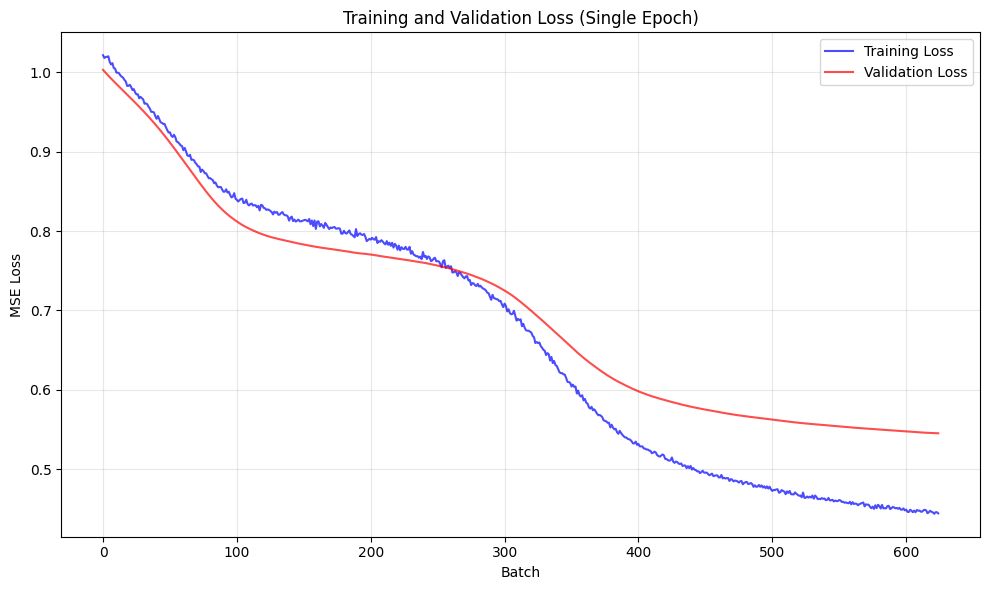


Training Summary:
Final training loss: 0.444373
Final validation loss: 0.545228
Average training loss: 0.668643
Average validation loss: 0.699696


In [35]:
# Set up training
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

# Create datasets
print("Creating training and validation datasets...")
train_dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples=CONFIG['n_samples'],
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    nonlinearity=None,
    seed=42,
    no_augmentation=False  # Generate augmented samples on-the-fly
)

# The validation set uses original embeddings (same size as train)
val_dataset = TranscriptomeEmbeddingDataset(
    original_embeddings=original_embeddings,
    n_samples=CONFIG['n_samples'],
    mlp_hidden_dim=CONFIG['mlp_hidden_dim'],
    mlp_n_layers=CONFIG['mlp_n_layers'],
    nonlinearity=None,
    seed=42 + CONFIG['n_samples'],  # Different seed for validation
    no_augmentation=True  # Always return original embeddings
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

# Track losses per batch
train_losses = []
val_losses = []

print("\nStarting training (single epoch)...")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Learning rate: {CONFIG['learning_rate']}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}\n")

# Single epoch training loop with validation at each batch
import time

epoch_start_time = time.time()

for batch_idx, (train_batch, val_batch) in enumerate(zip(train_loader, val_loader)):
    batch_start_time = time.time()
    train_batch = train_batch.to(device)
    val_batch = val_batch.to(device)
    
    # Training forward pass
    model.train()
    train_reconstructed, train_attn_weights, train_attn_scores = model(train_batch)
    train_loss = criterion(train_reconstructed, train_batch)
    
    # Training backward pass
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    # Validation forward pass (no gradient computation)
    model.eval()
    with torch.no_grad():
        val_reconstructed, _, _ = model(val_batch)
        val_loss = criterion(val_reconstructed, val_batch)
    
    # Track losses
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    
    # Print progress periodically
    if (batch_idx + 1) % 50 == 0:
        batch_time = time.time() - batch_start_time
        avg_train_loss_last_50 = np.mean(train_losses[-50:])
        avg_val_loss_last_50 = np.mean(val_losses[-50:])
        print(f"Batch {batch_idx+1}/{len(train_loader)}: "
              f"Train Loss: {train_loss.item():.6f}, "
              f"Val Loss: {val_loss.item():.6f}, "
              f"Avg Train (last 50): {avg_train_loss_last_50:.6f}, "
              f"Avg Val (last 50): {avg_val_loss_last_50:.6f}, "
              f"Time: {batch_time:.3f}s")

train_time = time.time() - epoch_start_time
print(f"\nTraining completed in {train_time:.2f}s ({train_time/60:.2f} min)")

# Plot training and validation loss curves
print("\nPlotting loss curves...")
plt.figure(figsize=(10, 6))

# Plot both curves
plt.plot(train_losses, alpha=0.7, label='Training Loss', color='blue')
plt.plot(val_losses, alpha=0.7, label='Validation Loss', color='red')

plt.xlabel('Batch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss (Single Epoch)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTraining Summary:")
print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")
print(f"Average training loss: {np.mean(train_losses):.6f}")
print(f"Average validation loss: {np.mean(val_losses):.6f}")

## 6. Visualization of Learned Attention Matrices

Now we visualize the learned attention patterns. The attention weights represent our learned "connectome" - how much each neuron needs to attend to every other neuron for reconstruction. We'll focus on analyzing the structure and patterns in the learned attention matrix.


Extracting learned attention on original embeddings...
Reconstruction MSE on original embeddings: 0.545228
Using attention weights
Learned attention matrix shape: (130, 130)
Attention matrix stats - mean: 0.007692, std: 0.052537
Attention matrix range: [0.000000, 0.999890]


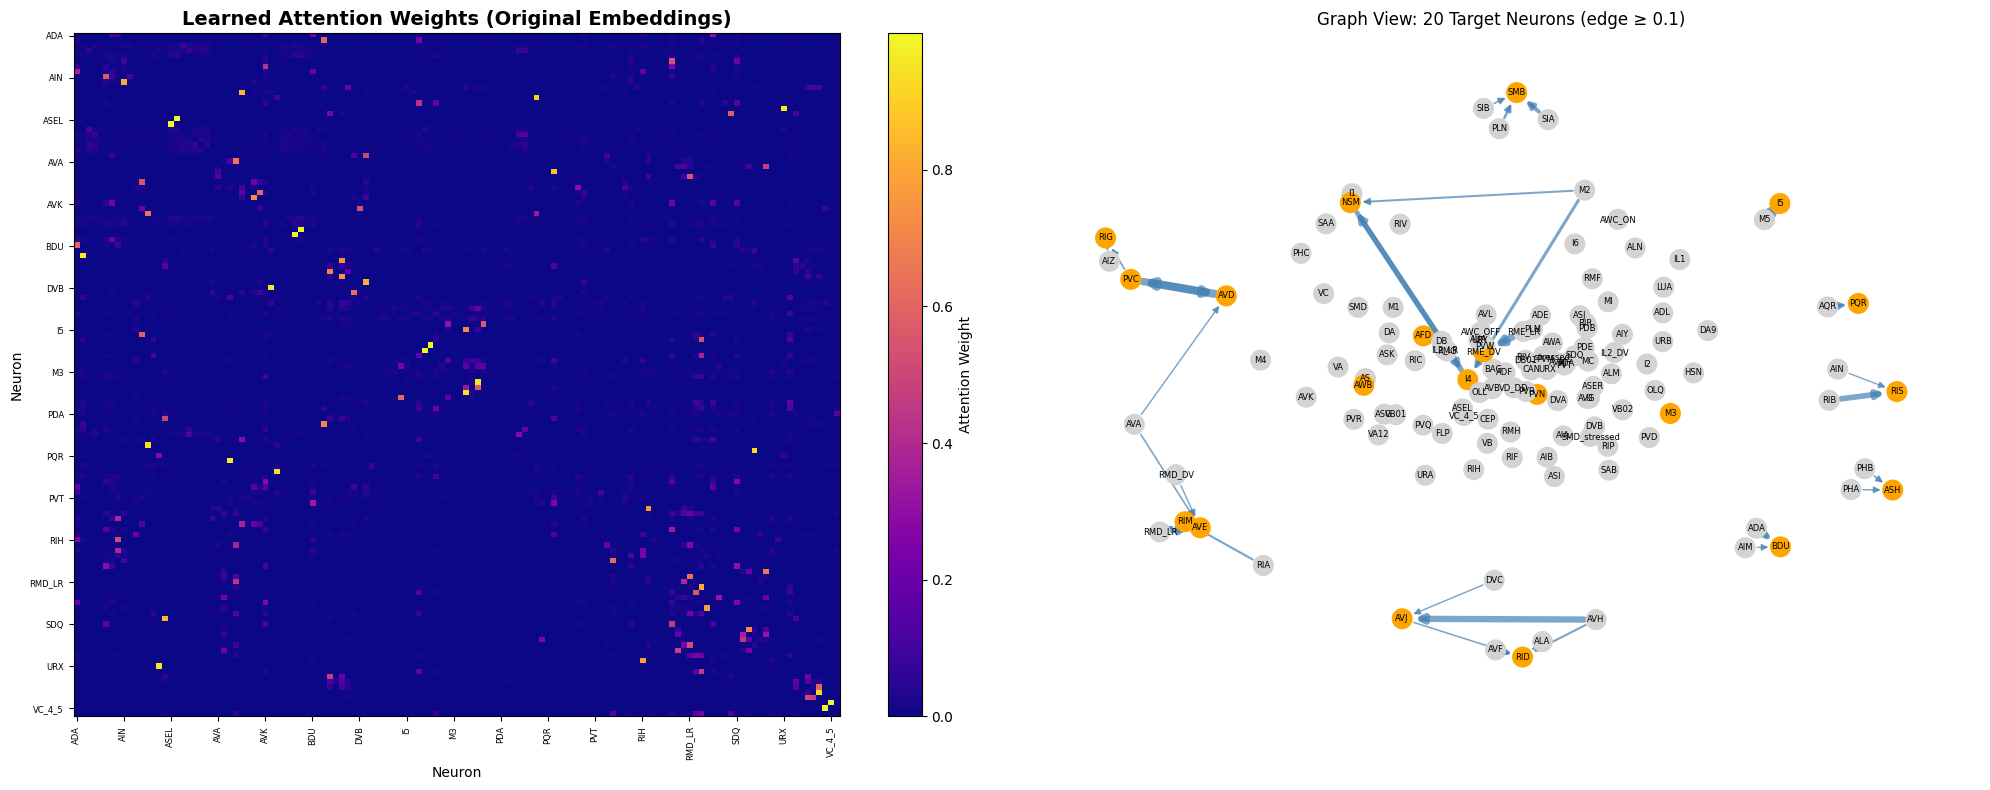

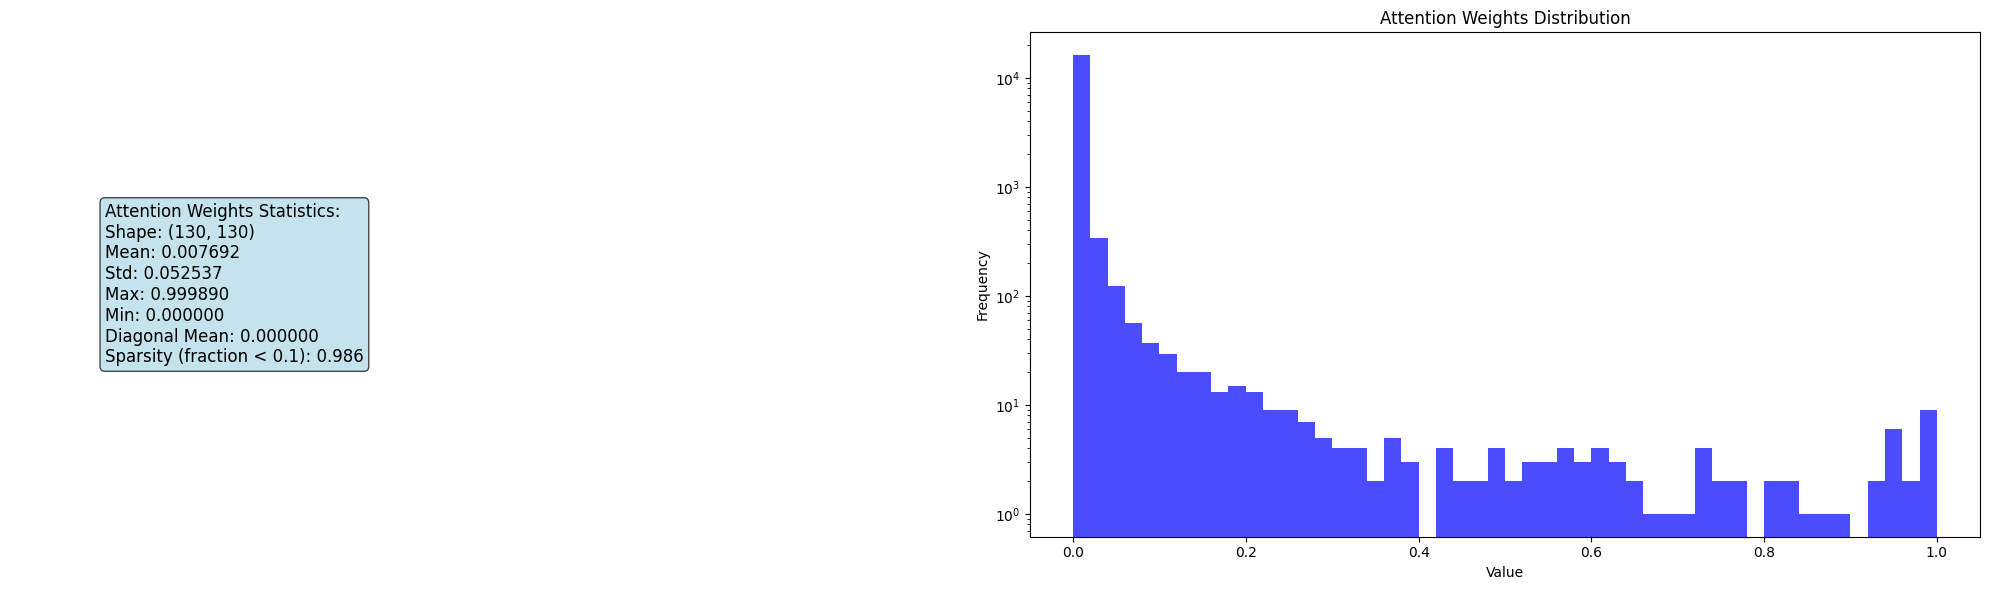


Summary (Original Embeddings):
Reconstruction MSE (attention): 0.545228
Attention weights sparsity@0.1: 0.986


In [36]:
# Evaluate learned attention on original embeddings and visualize
import networkx as nx

print("Extracting learned attention on original embeddings...")
model.eval()
with torch.no_grad():
    # Use the original embeddings as the test "batch" (batch size = 1)
    test_batch = original_embeddings.unsqueeze(0).to(device)  # (1, N, D)  

    reconstructed_orig, attn_weights, attn_scores = model(test_batch)

# Compute reconstruction MSE on original embeddings
mse_orig = torch.mean((reconstructed_orig - test_batch)**2).item()
print(f"Reconstruction MSE on original embeddings: {mse_orig:.6f}")

# Choose which attention matrix to use based on configuration
if CONFIG['use_attention_scores']:
    # Use attention scores (can be negative)
    avg_attention = attn_scores.mean(dim=0).cpu().numpy()  # (N, N)
    attention_type = "scores"
    attention_label = "Attention Score"
else:
    # Use attention weights (non-negative, sum to 1)
    avg_attention = attn_weights.mean(dim=0).cpu().numpy()  # (N, N)
    attention_type = "weights"
    attention_label = "Attention Weight"

attention_matrix = avg_attention

# Always use attention weights for sparsity calculations
attention_weights_matrix = attn_weights.mean(dim=0).cpu().numpy()  # (N, N)
attn_sparsity_thresh = 0.1
attention_sparsity_val = (attention_weights_matrix < attn_sparsity_thresh).sum() / attention_weights_matrix.size

print(f"Using attention {attention_type}")
print(f"Learned attention matrix shape: {attention_matrix.shape}")
print(f"Attention matrix stats - mean: {attention_matrix.mean():.6f}, std: {attention_matrix.std():.6f}")
print(f"Attention matrix range: [{attention_matrix.min():.6f}, {attention_matrix.max():.6f}]")

# First figure: Attention matrix and graph view
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 1) Learned attention matrix with sparsified tick labels
cmap = 'coolwarm' if CONFIG['use_attention_scores'] else 'plasma'
im1 = ax1.imshow(attention_matrix, cmap=cmap, aspect='auto')
ax1.set_title(f'Learned Attention {attention_type.title()} (Original Embeddings)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Neuron')
ax1.set_ylabel('Neuron')
plt.colorbar(im1, ax=ax1, label=attention_label)
# Label every k-th tick to reduce clutter
k = max(1, len(neuron_classes) // 16)  # ~16 labels per axis
xticks = np.arange(0, len(neuron_classes), k)
ax1.set_xticks(xticks)
ax1.set_xticklabels([neuron_classes[i] for i in xticks], fontsize=6, rotation=90)
ax1.set_yticks(xticks)
ax1.set_yticklabels([neuron_classes[i] for i in xticks], fontsize=6)

# 2) Graph plot for randomly selected target neurons
np.random.seed(42)
num_targets = 20
edge_thresh = 0.1  # filter weak edges
targets = np.random.choice(len(neuron_classes), size=num_targets, replace=False)
G = nx.DiGraph()
# Add nodes
for idx in range(len(neuron_classes)):
    G.add_node(idx, label=neuron_classes[idx])

# Add edges to selected targets above threshold (exclude self)
for j in targets:  # j is target
    for i in range(len(neuron_classes)):  # i is source
        if i == j:
            continue
        w = attention_weights_matrix[j, i]  # [target, source] for incoming edges
        if w >= edge_thresh:
            G.add_edge(i, j, weight=w)  # Edge from source i to target j

# Node positions (spectral layout)
pos = nx.forceatlas2_layout(G, scaling_ratio=0.05)
# Draw nodes (highlight selected targets)
node_colors = ['orange' if n in targets else 'lightgray' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors, ax=ax2)
# Draw edges with widths ~ weight
if G.number_of_edges() > 0:
    weights = np.array([d['weight'] for (_, _, d) in G.edges(data=True)])
    widths = 1.0 + 5.0 * (weights - weights.min()) / (np.ptp(weights) + 1e-8)
    nx.draw_networkx_edges(G, pos, width=widths, edge_color='steelblue', alpha=0.7, arrows=True, ax=ax2)
# Draw labels for nodes
labels = {n: neuron_classes[n] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6, ax=ax2)
ax2.set_title(f'Graph View: {num_targets} Target Neurons (edge ≥ {edge_thresh})')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Second figure: Statistics plots
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# 1) Statistics text box
ax1.axis('off')
stats_text = f"""Attention {attention_type.title()} Statistics:
Shape: {attention_matrix.shape}
Mean: {attention_matrix.mean():.6f}
Std: {attention_matrix.std():.6f}
Max: {attention_matrix.max():.6f}
Min: {attention_matrix.min():.6f}
Diagonal Mean: {np.diag(attention_matrix).mean():.6f}
Sparsity (fraction < {attn_sparsity_thresh}): {attention_sparsity_val:.3f}"""
ax1.text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

# 2) Value distributions
ax2.hist(attention_matrix.flatten(), bins=50, alpha=0.7, color='blue', label='Attention')
ax2.set_xlabel('Value')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Attention {attention_type.title()} Distribution')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("\nSummary (Original Embeddings):")
print(f"Reconstruction MSE (attention): {mse_orig:.6f}")
print(f"Attention weights sparsity@{attn_sparsity_thresh}: {attention_sparsity_val:.3f}")

### Idea check: does the attention matrix better embed neurons? 

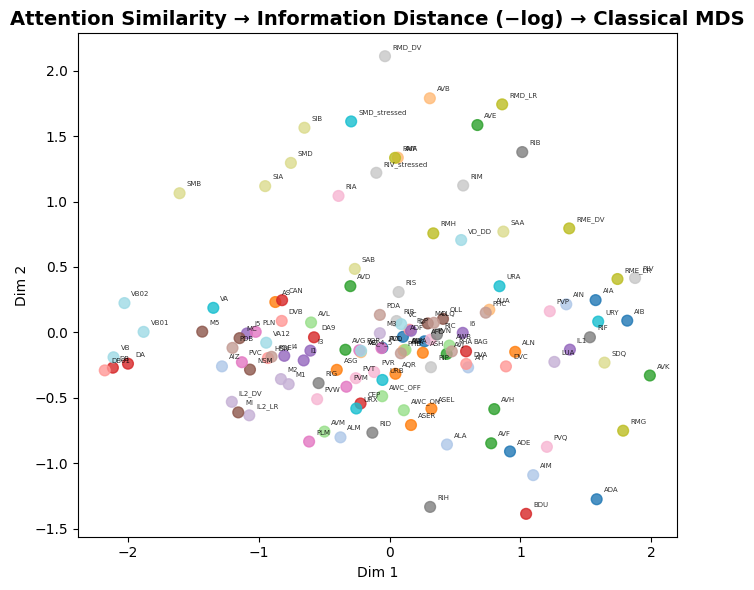

In [37]:
# Demo (Option B): Similarity → Information Distance → Classical MDS
# - Use the learned attention matrix A (rows softmaxed)
# - Symmetrize to get similarity S in [0,1]
# - Convert S to a steeper "information" distance with -log
# - Classical MDS from distances

# ----- Use the learned attention matrix -----
A = attention_matrix
n = A.shape[0]
J = np.eye(n) - np.ones((n, n)) / n

# Symmetrize to get a similarity matrix S \in [0,1]
S = 0.5 * (A + A.T)

# (Recommended) remove self-similarity so geometry comes from between-token relations
np.fill_diagonal(S, 0.0)

# ----- Similarity -> Distance (steeper than sqrt(1-S)) -----
# Information distance: D_ij = sqrt(max(0, -log(S_ij + eps)))
eps = 1e-9
D = np.sqrt(np.maximum(0.0, -np.log(S + eps)))

# ----- Classical MDS from pairwise distances -----
# Double-centering turns squared distances into a centered Gram matrix
B = -0.5 * J @ (D ** 2) @ J

# Eigendecomposition of Gram matrix; take top 2 components
eigvals, eigvecs = np.linalg.eigh(B)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

# Keep top 2 nonnegative components (guard against tiny negatives)
k = min(2, int((eigvals > 1e-12).sum()))
coords_mds = eigvecs[:, :k] * np.sqrt(np.maximum(eigvals[:k], 0.0))

# ----- Plot -----
plt.figure(figsize=(15, 6))
plt.scatter(coords_mds[:, 0], coords_mds[:, 1],
            c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
plt.title('Attention Similarity → Information Distance (−log) → Classical MDS',
          fontsize=14, fontweight='bold')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')

# Annotate every other neuron for readability
for i in range(0, len(neuron_classes), 1):
    plt.annotate(neuron_classes[i], (coords_mds[i, 0], coords_mds[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=5, alpha=0.8)

# (Optional) make aspect ratio equal for visual comparability
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

## 8. Ground-Truth Connectome Data Loading and Analysis

Now we'll load and analyze ground-truth connectome data to compare with our learned attention matrix. We have access to:

1. **Witvliet 2020 data** (`witvliet_2020_7.csv`, `witvliet_2020_8.csv`): From "Connectomes across development reveal principles of brain maturation" (Nature 596, 257–261, 2021)
2. **Randi 2023 data** (`CElegansFunctionalConnectivity.xlsx`): From "Neural signal propagation atlas of Caenorhabditis elegans" (Nature 623, 406–414, 2023)

These provide both wired (structural) and functional connectivity data that we can compare against our learned attention patterns.


In [38]:
# Load and analyze Witvliet 2020 connectome data
print("Loading Witvliet 2020 connectome data...")

# Load both datasets (they are tab-separated)
witvliet_7 = pd.read_csv('data/witvliet_2020_7.csv', sep='\t')
witvliet_8 = pd.read_csv('data/witvliet_2020_8.csv', sep='\t')

print(f"Witvliet 2020-7 shape: {witvliet_7.shape}")
print(f"Witvliet 2020-8 shape: {witvliet_8.shape}")
print(f"\nWitvliet 2020-7 columns: {witvliet_7.columns.tolist()}")
print(f"Witvliet 2020-8 columns: {witvliet_8.columns.tolist()}")

# Display sample data
print(f"\nWitvliet 2020-7 sample:")
print(witvliet_7.head())
print(f"\nWitvliet 2020-8 sample:")
print(witvliet_8.head())

# Analyze unique neurons in each dataset
neurons_7_pre = set(witvliet_7['pre'].unique())
neurons_7_post = set(witvliet_7['post'].unique())
neurons_7_all = neurons_7_pre.union(neurons_7_post)

neurons_8_pre = set(witvliet_8['pre'].unique())
neurons_8_post = set(witvliet_8['post'].unique())
neurons_8_all = neurons_8_pre.union(neurons_8_post)

# Union of all neurons across both datasets
neurons_7_8_all = neurons_7_all.union(neurons_8_all)

# Intersection of neurons across both datasets
neurons_7_8_overlap = neurons_7_all.intersection(neurons_8_all)

print(f"\nNeuron analysis:")
print(f"Witvliet 2020-7: {len(neurons_7_all)} unique neurons")
print(f"Witvliet 2020-8: {len(neurons_8_all)} unique neurons")
print(f"Union: {len(neurons_7_8_all)} neurons")
print(f"Overlap between 7 and 8: {len(neurons_7_8_overlap)} neurons")

# Check overlap with our transcriptome neuron classes
transcriptome_neurons = set(neuron_classes)
overlap_with_transcriptome = transcriptome_neurons.intersection(neurons_7_8_all)

print(f"\nOverlap with transcriptome data:")
print(f"Combined Witvliet overlap: {len(overlap_with_transcriptome)}/{len(transcriptome_neurons)} ({len(overlap_with_transcriptome)/len(transcriptome_neurons)*100:.1f}%)")
print(f"Sample overlapping neurons: {list(overlap_with_transcriptome)[:10]}")

# Analyze connection types
print(f"\nConnection type analysis:")
print(f"Witvliet 2020-7 types: {witvliet_7['type'].value_counts().to_dict()}")
print(f"Witvliet 2020-8 types: {witvliet_8['type'].value_counts().to_dict()}")

Loading Witvliet 2020 connectome data...
Witvliet 2020-7 shape: (2493, 4)
Witvliet 2020-8 shape: (2496, 4)

Witvliet 2020-7 columns: ['pre', 'post', 'type', 'synapses']
Witvliet 2020-8 columns: ['pre', 'post', 'type', 'synapses']

Witvliet 2020-7 sample:
    pre  post      type  synapses
0  ADAL  AIAL  chemical         2
1  ADAL  AIBL  chemical         2
2  ADAL  AIBR  chemical         1
3  ADAL  AVAL  chemical         1
4  ADAL  AVBL  chemical         7

Witvliet 2020-8 sample:
    pre  post        type  synapses
0  ADAL  ADAR  electrical         1
1  ADAL  ASHL  electrical         1
2  ADAL  AVAL    chemical         2
3  ADAL  AVAR    chemical         1
4  ADAL  AVBL    chemical        16

Neuron analysis:
Witvliet 2020-7: 222 unique neurons
Witvliet 2020-8: 219 unique neurons
Union: 223 neurons
Overlap between 7 and 8: 218 neurons

Overlap with transcriptome data:
Combined Witvliet overlap: 14/130 (10.8%)
Sample overlapping neurons: ['DVC', 'RID', 'ASER', 'ASEL', 'ALA', 'DVA', 'RIS'

In [39]:
# Convert ground-truth connectome data to combined adjacency matrix
print("Creating combined Witvliet 2020 connectome (averaged and symmetrized)...")

def create_adjacency_matrix(df, neuron_list, weight_col='synapses', synapse_type='chemical'):
    """Create adjacency matrix from connectome dataframe, filtering by synapse type."""
    n_neurons = len(neuron_list)
    adj_matrix = np.zeros((n_neurons, n_neurons))
    
    # Create mapping from neuron names to indices
    neuron_to_idx = {neuron: i for i, neuron in enumerate(neuron_list)}
    
    # Filter for only the specified synapse type
    df_filtered = df[df['type'] == synapse_type]
    print(f"  Using {synapse_type} synapses: {len(df_filtered)} connections")
    
    for _, row in df_filtered.iterrows():
        pre_neuron = row['pre']
        post_neuron = row['post']
        weight = row[weight_col]
        
        if pre_neuron in neuron_to_idx and post_neuron in neuron_to_idx:
            pre_idx = neuron_to_idx[pre_neuron]
            post_idx = neuron_to_idx[post_neuron]
            adj_matrix[pre_idx, post_idx] += weight  # Sum if multiple connections
    
    return adj_matrix

# Create full adjacency matrices for all neurons in union (chemical synapses only)
all_neurons = sorted(list(neurons_7_8_all))  # Sort for consistent ordering
print(f"\nCreating adjacency matrices for {len(all_neurons)} neurons...")

print("Witvliet 2020-7:")
gt_adj_7_full = create_adjacency_matrix(witvliet_7, all_neurons, synapse_type='chemical')

print("Witvliet 2020-8:")
gt_adj_8_full = create_adjacency_matrix(witvliet_8, all_neurons, synapse_type='chemical')

# Average element-wise (treating missing connections as 0)
gt_adj_combined = (gt_adj_7_full + gt_adj_8_full) / 2
print(f"\nCombined adjacency matrix shape: {gt_adj_combined.shape}")
print(f"Combined matrix stats - mean: {gt_adj_combined.mean():.6f}, std: {gt_adj_combined.std():.6f}, max: {gt_adj_combined.max():.1f}")

# Symmetrize: (A + A.T) / 2
gt_adj_combined_sym = (gt_adj_combined + gt_adj_combined.T) / 2
print(f"Symmetrized matrix stats - mean: {gt_adj_combined_sym.mean():.6f}, std: {gt_adj_combined_sym.std():.6f}, max: {gt_adj_combined_sym.max():.1f}")

# Extract submatrix for overlapping neurons with transcriptome
overlap_neurons = sorted(list(overlap_with_transcriptome))  # Sort for consistent ordering
print(f"\nUsing {len(overlap_neurons)} overlapping neurons for comparison")

overlap_indices_gt = [all_neurons.index(n) for n in overlap_neurons]
overlap_indices_attn = [neuron_classes.index(n) for n in overlap_neurons]

gt_adj_final = gt_adj_combined_sym[np.ix_(overlap_indices_gt, overlap_indices_gt)]
attention_submatrix = attention_matrix[np.ix_(overlap_indices_attn, overlap_indices_attn)]

print(f"Ground-truth adjacency matrix (final) shape: {gt_adj_final.shape}")
print(f"Attention submatrix shape: {attention_submatrix.shape}")

print(f"\nFinal matrix statistics:")
print(f"GT Combined (Chemical, Symmetrized): mean={gt_adj_final.mean():.6f}, std={gt_adj_final.std():.6f}, max={gt_adj_final.max():.1f}")
print(f"Attention: mean={attention_submatrix.mean():.6f}, std={attention_submatrix.std():.6f}, max={attention_submatrix.max():.6f}")

# Verify symmetry
symmetry_error = np.abs(gt_adj_final - gt_adj_final.T).max()
print(f"Symmetry verification (max |A - A.T|): {symmetry_error:.10f}")

# Define attention type and label for consistency with visualization code
if CONFIG['use_attention_scores']:
    attention_type = "scores"
    attention_label = "Attention Score"
else:
    attention_type = "weights"
    attention_label = "Attention Weight"

# Always use attention weights for sparsity calculations (simplified approach)
attention_weights_submatrix = attention_weights_matrix[np.ix_(overlap_indices_attn, overlap_indices_attn)]

# Normalize matrices for comparison (0-1 scale)
def normalize_matrix(mat):
    """Normalize matrix to 0-1 scale."""
    # Convert to numpy array if it's a pandas DataFrame
    if hasattr(mat, 'values'):
        mat = mat.values
    mat_max = mat.max()
    mat_min = mat.min()
    if mat_max > mat_min:
        return (mat - mat_min) / (mat_max - mat_min)
    else:
        return mat

gt_adj_norm = normalize_matrix(gt_adj_final)
attention_norm = normalize_matrix(attention_submatrix)

Creating combined Witvliet 2020 connectome (averaged and symmetrized)...

Creating adjacency matrices for 223 neurons...
Witvliet 2020-7:
  Using chemical synapses: 2202 connections
Witvliet 2020-8:
  Using chemical synapses: 2186 connections

Combined adjacency matrix shape: (223, 223)
Combined matrix stats - mean: 0.155211, std: 1.093865, max: 36.5
Symmetrized matrix stats - mean: 0.155211, std: 0.853160, max: 35.8

Using 14 overlapping neurons for comparison
Ground-truth adjacency matrix (final) shape: (14, 14)
Attention submatrix shape: (14, 14)

Final matrix statistics:
GT Combined (Chemical, Symmetrized): mean=0.221939, std=0.802883, max=4.5
Attention: mean=0.023344, std=0.125693, max=0.999684
Symmetry verification (max |A - A.T|): 0.0000000000


Creating comparison visualizations...


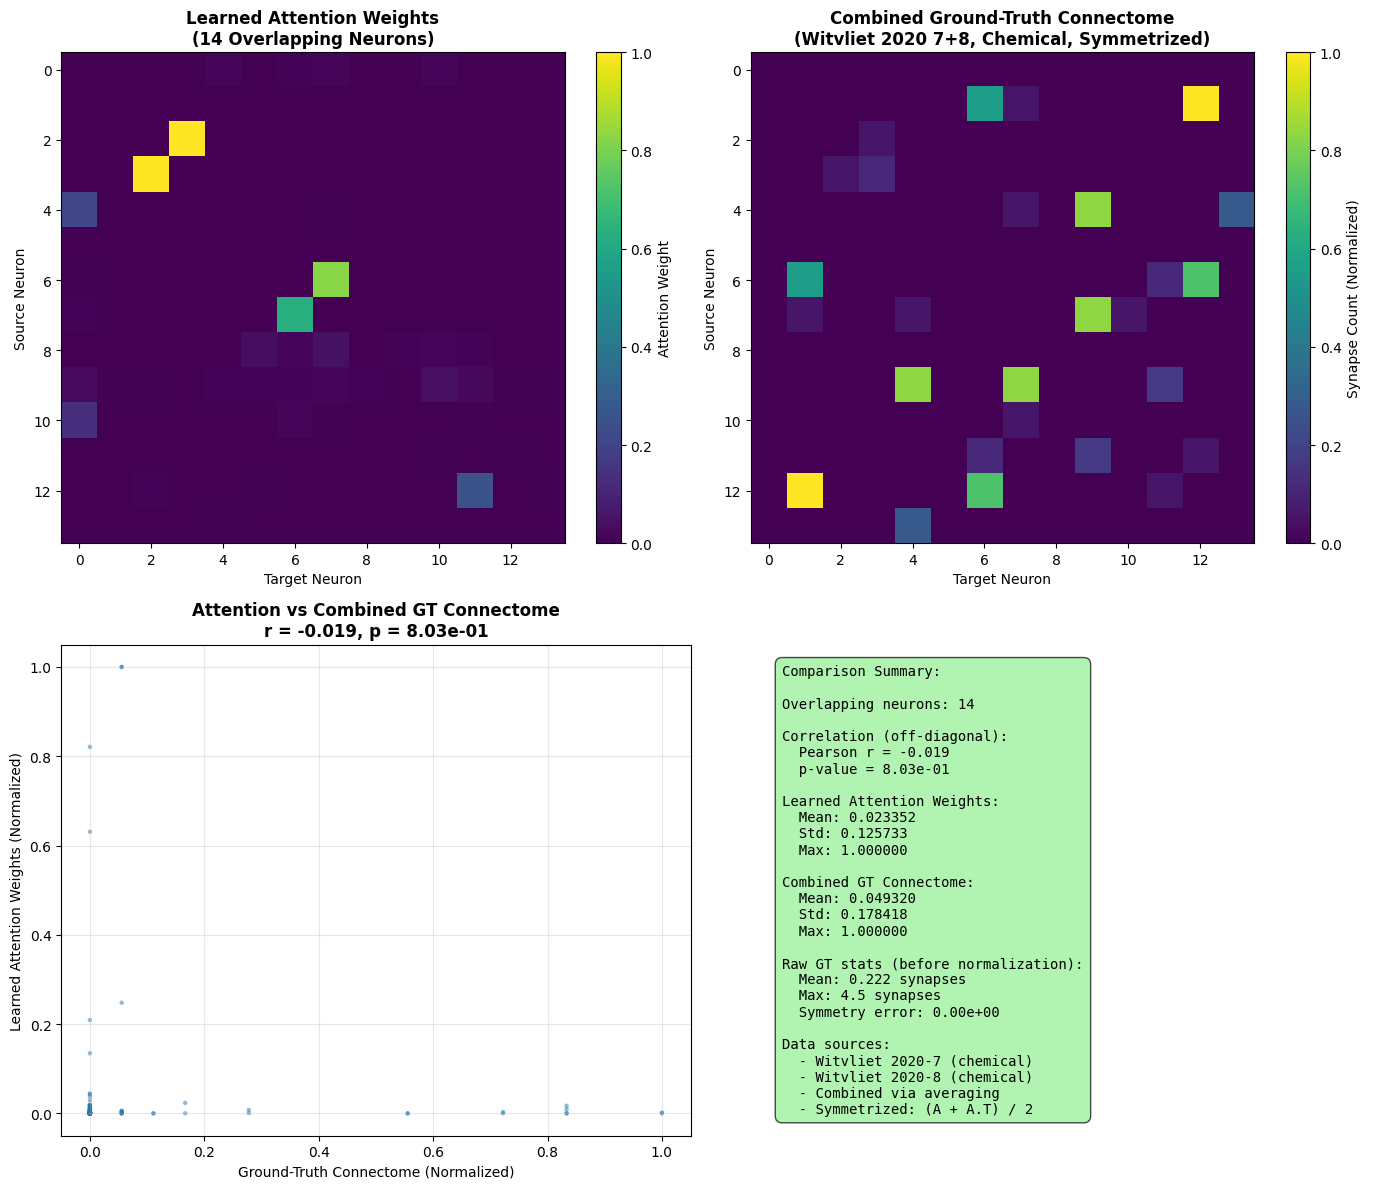


GROUND-TRUTH CONNECTOME CORRELATION ANALYSIS
Attention weights vs Combined Witvliet Connectome (Chemical, Symmetrized):
  Pearson r = -0.019
  p-value = 8.03e-01
  Valid data points: 182



In [40]:
# Visualize comparison between learned attention and combined ground-truth connectome
print("Creating comparison visualizations...")

from scipy.stats import pearsonr

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1) Learned attention matrix (subset)
im1 = axes[0, 0].imshow(attention_norm, cmap='viridis', aspect='auto')
axes[0, 0].set_title(f'Learned Attention {attention_type.title()}\n({len(overlap_neurons)} Overlapping Neurons)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Target Neuron')
axes[0, 0].set_ylabel('Source Neuron')
plt.colorbar(im1, ax=axes[0, 0], label=attention_label)

# 2) Combined ground-truth connectome
im2 = axes[0, 1].imshow(gt_adj_norm, cmap='viridis', aspect='auto')
axes[0, 1].set_title('Combined Ground-Truth Connectome\n(Witvliet 2020 7+8, Chemical, Symmetrized)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Target Neuron')
axes[0, 1].set_ylabel('Source Neuron')
plt.colorbar(im2, ax=axes[0, 1], label='Synapse Count (Normalized)')

# 3) Correlation analysis
# Flatten matrices for correlation
attn_flat = attention_norm.flatten()
gt_flat = gt_adj_norm.flatten()

# Remove diagonal elements for correlation (since attention diagonal is always 0)
mask = ~np.eye(attention_norm.shape[0], dtype=bool).flatten()
attn_flat_offdiag = attn_flat[mask]
gt_flat_offdiag = gt_flat[mask]

corr, p_val = pearsonr(attn_flat_offdiag, gt_flat_offdiag)

# Scatter plot
axes[1, 0].scatter(gt_flat_offdiag, attn_flat_offdiag, alpha=0.5, s=10, edgecolors='none')
axes[1, 0].set_xlabel('Ground-Truth Connectome (Normalized)')
axes[1, 0].set_ylabel(f'Learned Attention {attention_type.title()} (Normalized)')
axes[1, 0].set_title(f'Attention vs Combined GT Connectome\nr = {corr:.3f}, p = {p_val:.2e}', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4) Summary statistics
axes[1, 1].axis('off')
summary_text = f"""Comparison Summary:

Overlapping neurons: {len(overlap_neurons)}

Correlation (off-diagonal):
  Pearson r = {corr:.3f}
  p-value = {p_val:.2e}

Learned Attention {attention_type.title()}:
  Mean: {attention_norm.mean():.6f}
  Std: {attention_norm.std():.6f}
  Max: {attention_norm.max():.6f}

Combined GT Connectome:
  Mean: {gt_adj_norm.mean():.6f}
  Std: {gt_adj_norm.std():.6f}
  Max: {gt_adj_norm.max():.6f}
  
Raw GT stats (before normalization):
  Mean: {gt_adj_final.mean():.3f} synapses
  Max: {gt_adj_final.max():.1f} synapses
  Symmetry error: {symmetry_error:.2e}

Data sources:
  - Witvliet 2020-7 (chemical)
  - Witvliet 2020-8 (chemical)
  - Combined via averaging
  - Symmetrized: (A + A.T) / 2"""

axes[1, 1].text(0.05, 0.5, summary_text, fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7),
                family='monospace')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"GROUND-TRUTH CONNECTOME CORRELATION ANALYSIS")
print(f"{'='*60}")
print(f"Attention {attention_type} vs Combined Witvliet Connectome (Chemical, Symmetrized):")
print(f"  Pearson r = {corr:.3f}")
print(f"  p-value = {p_val:.2e}")
print(f"  Valid data points: {len(attn_flat_offdiag)}")
print(f"{'='*60}\n")